# Trabajo Práctico Final — Inteligencia Artificial

## PlantVillage — Clasificación de imágenes de hojas

**Universidad Nacional Guillermo Brown (UNaB)**  
**Materia:** Inteligencia Artificial  
**Grupo:** 1  
**Dataset:** PlantVillage  

---

## Etapa 1 — Análisis Exploratorio de Datos y Modelo Baseline

### 1. Objetivo

En esta etapa se caracteriza el dataset PlantVillage, se analiza la distribución de las clases y se revisa la independencia entre las particiones originales. A partir de la evidencia obtenida se define un esquema experimental Train/Dev/Test y la variable objetivo para el posterior desarrollo del modelo baseline.


### 2. Entorno y carga del dataset

Se registra el entorno de ejecución y se descarga la versión utilizada del dataset para favorecer la reproducibilidad del trabajo.


In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from dotenv import load_dotenv

print("Python:", sys.version)
print("Ejecutable:", sys.executable)

load_dotenv()

if not os.getenv("KAGGLE_API_TOKEN"):
    raise RuntimeError("KAGGLE_API_TOKEN no encontrada en el entorno.")

print("Autenticación Kaggle disponible")


Python: 3.12.5 (tags/v3.12.5:ff3bc82, Aug  6 2024, 20:45:27) [MSC v.1940 64 bit (AMD64)]
Ejecutable: D:\Users\Usuario\Pablo\Unab\InteligenciaArtificial\TP_Final_PlantVillage\.venv\Scripts\python.exe
Autenticación Kaggle disponible


In [2]:
import kagglehub

DATASET_ID = "tushar5harma/plant-village-dataset-updated"
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

dataset_path = Path(
    kagglehub.dataset_download(
        DATASET_ID,
        output_dir=str(DATA_DIR)
    )
)

print("Dataset:", DATASET_ID)
print("Ruta local:", dataset_path.resolve())


D:\Users\Usuario\Pablo\Unab\InteligenciaArtificial\TP_Final_PlantVillage\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset: tushar5harma/plant-village-dataset-updated
Ruta local: D:\Users\Usuario\Pablo\Unab\InteligenciaArtificial\TP_Final_PlantVillage\data


### 3. Análisis exploratorio

#### 3.1 Estructura general

Se construye una tabla con una fila por imagen. La etiqueta de clasificación corresponde a la combinación **especie + condición**. El UUID inicial del nombre de archivo se conserva como identificador de familia para analizar imágenes relacionadas.


In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

species_paths = sorted(
    p for p in dataset_path.iterdir()
    if p.is_dir() and not p.name.startswith(".")
)

records = []

for species_path in species_paths:
    for split in ["Train", "Val", "Test"]:
        split_path = species_path / split

        class_paths = sorted(
            p for p in split_path.iterdir()
            if p.is_dir() and not p.name.startswith(".")
        )

        for class_path in class_paths:
            for file in class_path.rglob("*"):
                if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS:
                    records.append({
                        "Especie": species_path.name,
                        "Clase": class_path.name,
                        "ParticionOriginal": split,
                        "Archivo": file.name,
                        "Ruta": str(file)
                    })

df_images = pd.DataFrame(records)

df_images["UUID"] = df_images["Archivo"].str[:36]
df_images["Etiqueta"] = (
    df_images["Especie"].astype(str)
    + " | "
    + df_images["Clase"].astype(str)
)

print(f"Imágenes: {len(df_images):,}")
print(f"Especies: {df_images['Especie'].nunique()}")
print(f"Clases especie-condición: {df_images['Etiqueta'].nunique()}")
print(f"Familias UUID: {df_images['UUID'].nunique():,}")

print("\nImágenes por partición original:")
print(
    df_images["ParticionOriginal"]
    .value_counts()
    .reindex(["Train", "Val", "Test"])
)


Imágenes: 67,118
Especies: 9
Clases especie-condición: 29
Familias UUID: 33,879

Imágenes por partición original:
ParticionOriginal
Train    53693
Val      12067
Test      1358
Name: count, dtype: int64


#### 3.2 Distribución de las clases

Se analiza la cantidad total de imágenes de cada combinación especie-condición. Esta es la primera aproximación al balance del problema.


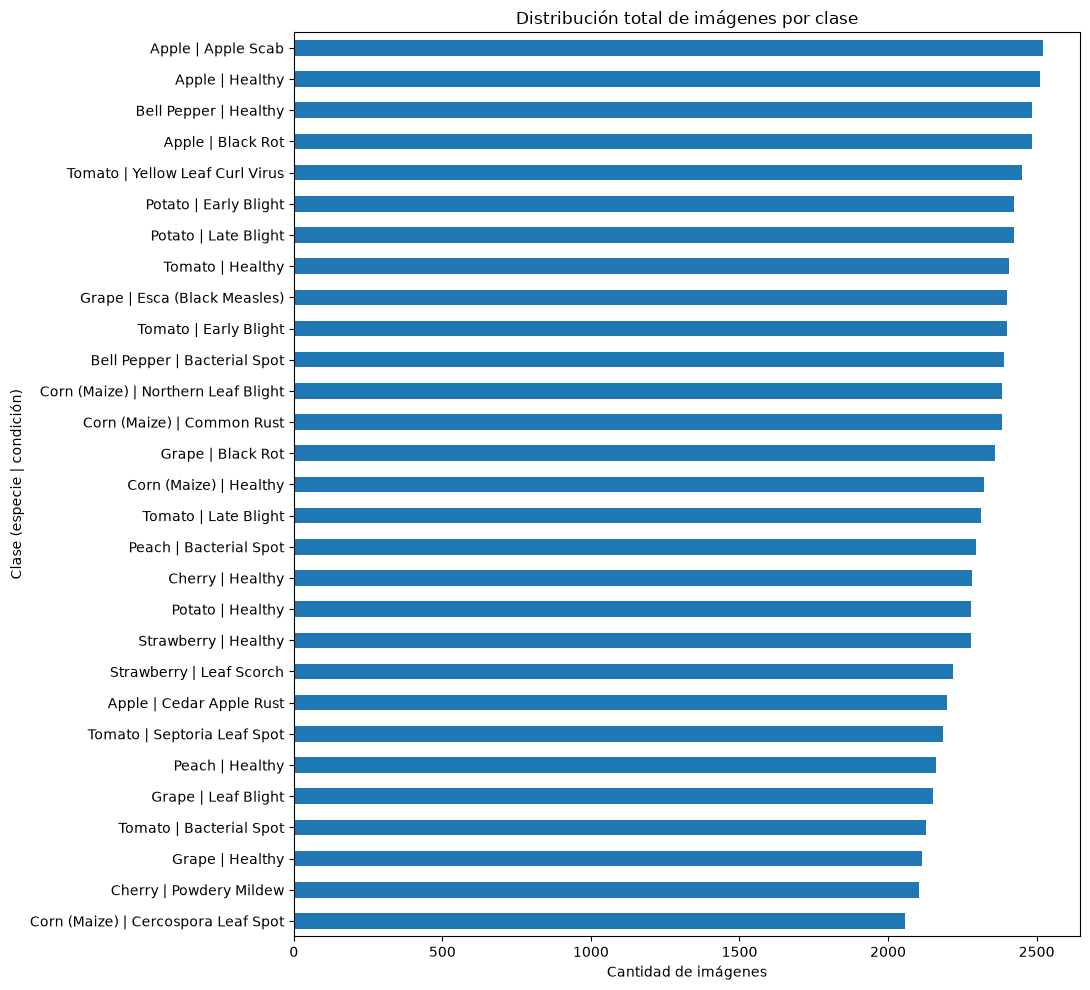

Mínimo: 2,056 imágenes
Máximo: 2,520 imágenes
Relación máxima/mínima: 1.23


In [4]:
class_totals = (
    df_images
    .groupby("Etiqueta")
    .size()
    .sort_values()
)

ax = class_totals.plot(
    kind="barh",
    figsize=(11, 10)
)

ax.set_title("Distribución total de imágenes por clase")
ax.set_xlabel("Cantidad de imágenes")
ax.set_ylabel("Clase (especie | condición)")

plt.tight_layout()
plt.show()

print(f"Mínimo: {class_totals.min():,} imágenes")
print(f"Máximo: {class_totals.max():,} imágenes")
print(f"Relación máxima/mínima: {class_totals.max() / class_totals.min():.2f}")


**Interpretación.** Las 29 clases presentan cantidades de imágenes relativamente homogéneas. Sin embargo, el balance por cantidad de archivos no garantiza que todos los ejemplos sean independientes, porque el dataset contiene variantes asociadas a una misma imagen base.


#### 3.3 Diversidad a nivel de familia UUID

Antes de utilizar el UUID como unidad de agrupamiento se verifica que cada UUID corresponda a una única etiqueta. Luego se compara la cantidad de imágenes con la cantidad de familias independientes disponibles por clase.


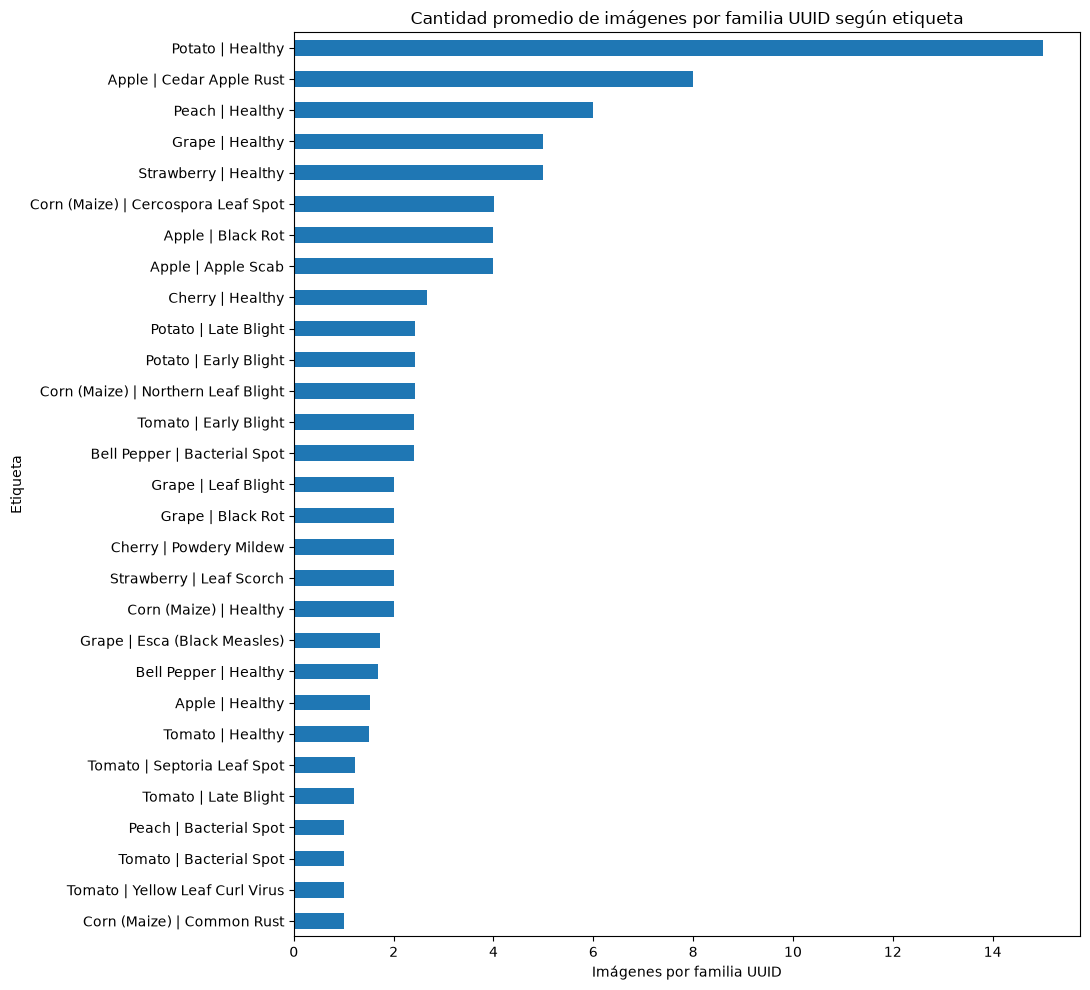

UUID asociados a más de una etiqueta: 0
Rango de familias UUID por clase: 152 a 2,451


In [5]:
uuid_label_counts = (
    df_images
    .groupby("UUID")["Etiqueta"]
    .nunique()
)

assert (uuid_label_counts == 1).all(), (
    "Se encontraron UUID asociados a más de una etiqueta."
)

df_diversidad = (
    df_images
    .groupby("Etiqueta")
    .agg(
        Imagenes=("Archivo", "size"),
        Familias_UUID=("UUID", "nunique")
    )
)

df_diversidad["Imagenes_por_familia"] = (
    df_diversidad["Imagenes"]
    / df_diversidad["Familias_UUID"]
)

df_diversidad = df_diversidad.sort_values("Imagenes_por_familia")

ax = df_diversidad["Imagenes_por_familia"].plot(
    kind="barh",
    figsize=(11, 10)
)

ax.set_title("Cantidad promedio de imágenes por familia UUID según etiqueta")
ax.set_xlabel("Imágenes por familia UUID")
ax.set_ylabel("Etiqueta")

plt.tight_layout()
plt.show()

print("UUID asociados a más de una etiqueta: 0")
print(
    "Rango de familias UUID por clase:",
    f"{df_diversidad['Familias_UUID'].min():,}",
    "a",
    f"{df_diversidad['Familias_UUID'].max():,}"
)


**Interpretación.** Aunque las clases están relativamente balanceadas por cantidad de archivos, la cantidad de familias UUID varía de forma considerable. Por lo tanto, el número de imágenes no representa directamente la diversidad de muestras independientes.


#### 3.4 Solapamiento de familias en las particiones originales

Se verifica qué proporción de las imágenes de Validation y Test pertenece a familias UUID que también aparecen en el Train original.


,Particion,Total,Familia_en_Train,Porcentaje
0,Val,12067,8226,68.17
1,Test,1358,918,67.60


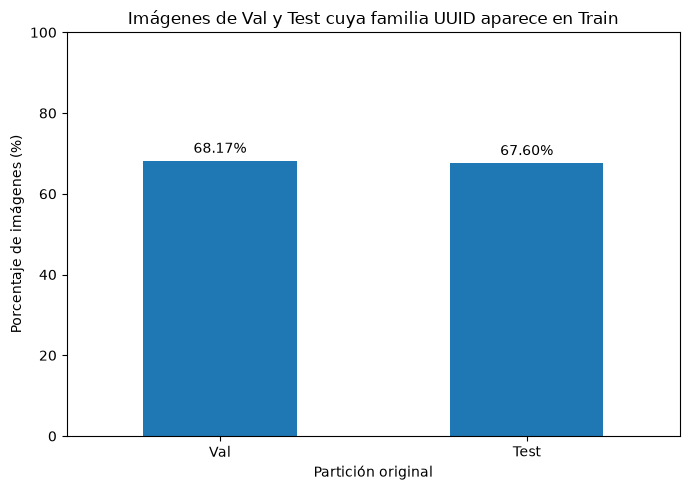

In [6]:
uuids_train_original = set(
    df_images.loc[
        df_images["ParticionOriginal"] == "Train",
        "UUID"
    ]
)

datos_solapamiento = []

for particion in ["Val", "Test"]:
    df_particion = df_images[
        df_images["ParticionOriginal"] == particion
    ]

    comparte_familia = df_particion["UUID"].isin(uuids_train_original)

    datos_solapamiento.append({
        "Particion": particion,
        "Total": len(df_particion),
        "Familia_en_Train": int(comparte_familia.sum()),
        "Porcentaje": comparte_familia.mean() * 100
    })

df_solapamiento = pd.DataFrame(datos_solapamiento)
display(df_solapamiento.round(2))

ax = df_solapamiento.set_index("Particion")["Porcentaje"].plot(
    kind="bar",
    figsize=(7, 5)
)

ax.set_title("Imágenes de Val y Test cuya familia UUID aparece en Train")
ax.set_xlabel("Partición original")
ax.set_ylabel("Porcentaje de imágenes (%)")
ax.set_ylim(0, 100)

for i, valor in enumerate(df_solapamiento["Porcentaje"]):
    ax.text(i, valor + 2, f"{valor:.2f}%", ha="center")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretación.** Se observa un solapamiento elevado de familias entre el Train original y los conjuntos destinados a evaluación. Esto no implica que sean archivos idénticos: son imágenes asociadas al mismo UUID y pueden corresponder a variantes de una misma muestra. Para evitar dependencia entre entrenamiento y evaluación, la partición experimental se realizará a nivel de familia UUID.


#### 3.5 Inspección visual de las clases

Se muestra una imagen de cada combinación especie-condición para observar diferencias visuales generales, fondos, encuadres y posibles señales contextuales que puedan resultar relevantes durante el análisis de errores.


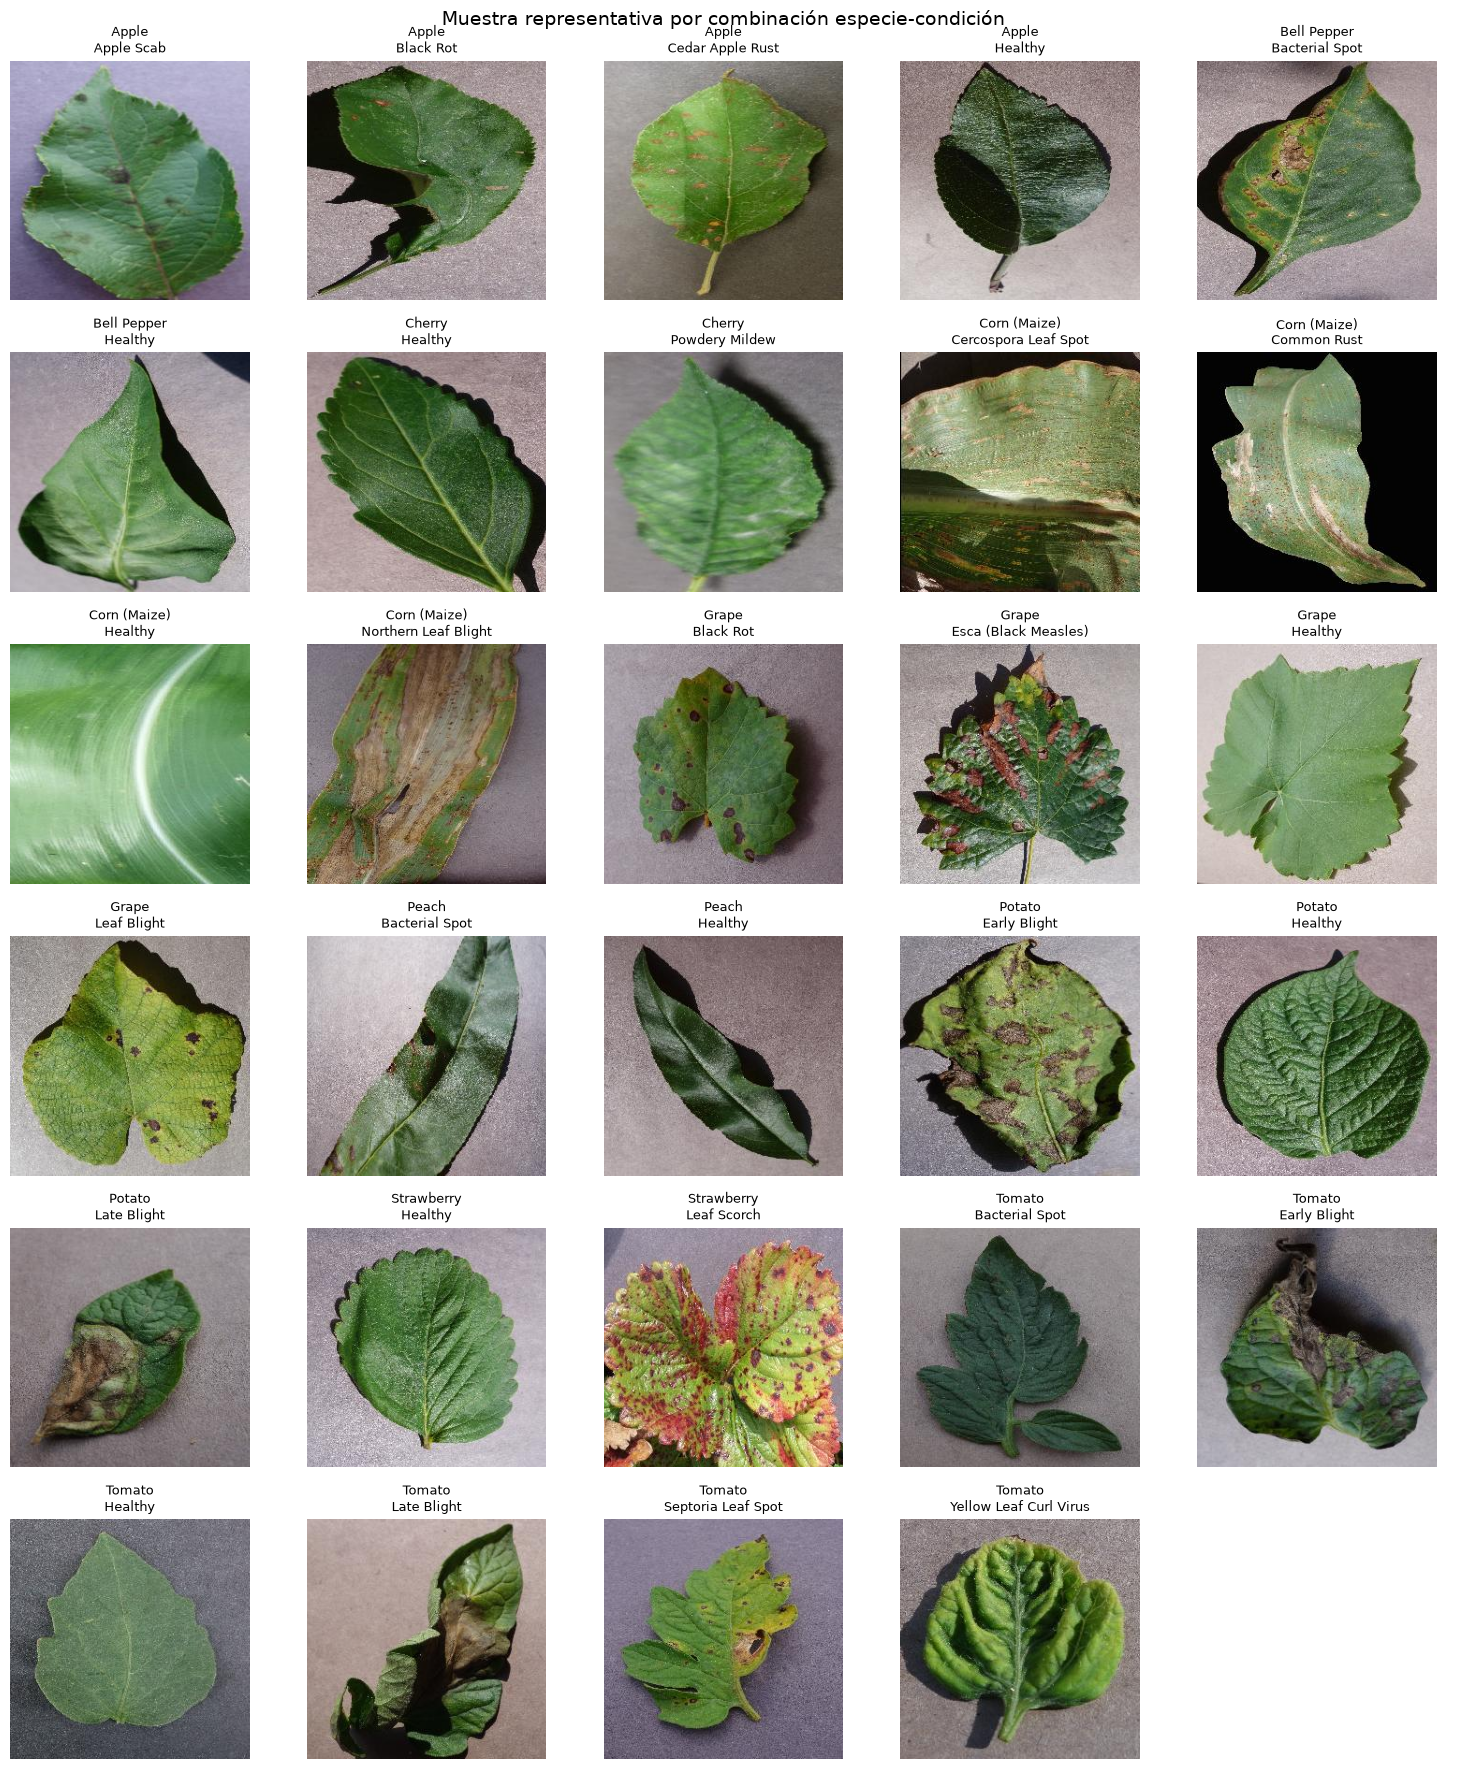

In [7]:
muestra_clases = (
    df_images[df_images["ParticionOriginal"] == "Train"]
    .sort_values(["Especie", "Clase", "Archivo"])
    .groupby(["Especie", "Clase"], as_index=False)
    .first()
)

n_cols = 5
n_rows = (len(muestra_clases) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, n_rows * 3)
)

axes = axes.flatten()

for ax, (_, fila) in zip(axes, muestra_clases.iterrows()):
    with Image.open(fila["Ruta"]) as img:
        ax.imshow(img)

    ax.set_title(
        f"{fila['Especie']}\n{fila['Clase']}",
        fontsize=9
    )
    ax.axis("off")

for ax in axes[len(muestra_clases):]:
    ax.axis("off")

plt.suptitle(
    "Muestra representativa por combinación especie-condición",
    fontsize=14
)

plt.tight_layout()
plt.show()


**Observación.** La inspección visual muestra variaciones tanto en las hojas como en el contexto de las imágenes: fondos relativamente homogéneos, sombras, encuadres y zonas oscuras asociadas a algunas transformaciones. Estas características se tendrán en cuenta posteriormente para el análisis manual de errores.


### 4. Reconstrucción de Train, Dev y Test

Las particiones experimentales se construyen con dos criterios:

- **Agrupamiento por UUID:** todas las imágenes de una misma familia permanecen en una única partición.
- **Estratificación por etiqueta:** se preserva aproximadamente la distribución de las 29 combinaciones especie-condición.

Se utiliza una proporción **80 % Train / 10 % Dev / 10 % Test**. Todas las imágenes se conservan; únicamente se reasigna su función experimental. Test queda reservado para la evaluación final del mejor modelo.


In [8]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

df_familias = (
    df_images
    .groupby("UUID")
    .agg(
        Especie=("Especie", "first"),
        Clase=("Clase", "first"),
        Etiqueta=("Etiqueta", "first"),
        CantidadImagenes=("Archivo", "size")
    )
    .reset_index()
)

# 90 % Train+Dev / 10 % Test
familias_train_dev, familias_test = train_test_split(
    df_familias,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=df_familias["Etiqueta"]
)

# Del 90 % anterior, 1/9 corresponde a Dev:
# (1/9) * 90 % = 10 % del total.
familias_train, familias_dev = train_test_split(
    familias_train_dev,
    test_size=1/9,
    random_state=RANDOM_STATE,
    stratify=familias_train_dev["Etiqueta"]
)

uuids_train = set(familias_train["UUID"])
uuids_dev = set(familias_dev["UUID"])
uuids_test = set(familias_test["UUID"])

# Independencia entre particiones.
assert uuids_train.isdisjoint(uuids_dev)
assert uuids_train.isdisjoint(uuids_test)
assert uuids_dev.isdisjoint(uuids_test)
assert len(uuids_train | uuids_dev | uuids_test) == len(df_familias)

mapa_particiones = {
    **{uuid: "Train" for uuid in uuids_train},
    **{uuid: "Dev" for uuid in uuids_dev},
    **{uuid: "Test" for uuid in uuids_test},
}

df_images["ParticionExperimental"] = (
    df_images["UUID"].map(mapa_particiones)
)

assert df_images["ParticionExperimental"].notna().all()

df_train = df_images[
    df_images["ParticionExperimental"] == "Train"
].copy()

df_dev = df_images[
    df_images["ParticionExperimental"] == "Dev"
].copy()

df_test = df_images[
    df_images["ParticionExperimental"] == "Test"
].copy()

print("Familias UUID:")
print(f"  Train: {len(uuids_train):,}")
print(f"  Dev:   {len(uuids_dev):,}")
print(f"  Test:  {len(uuids_test):,}")

print("\nImágenes:")
print(f"  Train: {len(df_train):,}")
print(f"  Dev:   {len(df_dev):,}")
print(f"  Test:  {len(df_test):,}")
print(f"  Total: {len(df_images):,}")


Familias UUID:
  Train: 27,103
  Dev:   3,388
  Test:  3,388

Imágenes:
  Train: 53,684
  Dev:   6,712
  Test:  6,722
  Total: 67,118


#### 4.1 Verificación de la estratificación

Se comprueba que las 29 etiquetas estén representadas en las tres particiones y que las proporciones por clase permanezcan próximas a 80/10/10.


In [9]:
conteos = pd.DataFrame({
    "Train": familias_train["Etiqueta"].value_counts(),
    "Dev": familias_dev["Etiqueta"].value_counts(),
    "Test": familias_test["Etiqueta"].value_counts()
}).fillna(0).astype(int)

conteos["Total"] = conteos.sum(axis=1)

for particion in ["Train", "Dev", "Test"]:
    conteos[f"{particion}_%"] = (
        conteos[particion] / conteos["Total"] * 100
    )

assert (conteos[["Train", "Dev", "Test"]] > 0).all().all()
assert len(conteos) == 29

display(
    conteos[
        ["Train", "Dev", "Test", "Train_%", "Dev_%", "Test_%"]
    ].round(2)
)

print("\n✓ 29 etiquetas presentes en Train, Dev y Test.")
print("✓ Solapamiento de UUID entre particiones: 0.")
print("✓ Todas las imágenes fueron conservadas.")


,Train,Dev,Test,Train_%,Dev_%,Test_%
Etiqueta,,,,,,
Apple | Apple Scab,504,63,63,80.00,10.00,10.00
Apple | Black Rot,497,62,62,80.03,9.98,9.98
Apple | Cedar Apple Rust,220,28,27,80.00,10.18,9.82
Apple | Healthy,1316,164,165,80.00,9.97,10.03
Bell Pepper | Bacterial Spot,797,100,100,79.94,10.03,10.03
Bell Pepper | Healthy,1181,148,148,79.96,10.02,10.02
Cherry | Healthy,684,85,85,80.09,9.95,9.95
Cherry | Powdery Mildew,842,105,105,80.04,9.98,9.98
Corn (Maize) | Cercospora Leaf Spot,411,51,51,80.12,9.94,9.94



✓ 29 etiquetas presentes en Train, Dev y Test.
✓ Solapamiento de UUID entre particiones: 0.
✓ Todas las imágenes fueron conservadas.


### 5. Variable objetivo

El problema se formula como una **clasificación multiclase de 29 categorías**. Cada categoría representa una combinación entre especie vegetal y condición de la hoja. Las etiquetas textuales se codifican con enteros de 0 a 28 utilizando el mismo mapping para Train, Dev y Test.


In [10]:
etiquetas = sorted(df_train["Etiqueta"].unique())

label_to_id = {
    etiqueta: idx
    for idx, etiqueta in enumerate(etiquetas)
}

id_to_label = {
    idx: etiqueta
    for etiqueta, idx in label_to_id.items()
}

for df in [df_train, df_dev, df_test]:
    df["Label"] = df["Etiqueta"].map(label_to_id)

assert len(label_to_id) == 29
assert df_train["Label"].notna().all()
assert df_dev["Label"].notna().all()
assert df_test["Label"].notna().all()
assert df_train["Label"].nunique() == 29
assert df_dev["Label"].nunique() == 29
assert df_test["Label"].nunique() == 29

print(f"Número de clases: {len(label_to_id)}")
print(
    "Tamaños:",
    f"Train={len(df_train):,},",
    f"Dev={len(df_dev):,},",
    f"Test={len(df_test):,}"
)

display(df_train[["Ruta", "Etiqueta", "Label", "UUID"]].head())


Número de clases: 29
Tamaños: Train=53,684, Dev=6,712, Test=6,722


,Ruta,Etiqueta,Label,UUID
0,data\Apple\Train\Apple Scab\00075aa8-d81a-4184...,Apple | Apple Scab,0,00075aa8-d81a-4184-8541-b692b78d398a
5,data\Apple\Train\Apple Scab\01f3deaa-6143-4b6c...,Apple | Apple Scab,0,01f3deaa-6143-4b6c-9c22-620a46d8be04
6,data\Apple\Train\Apple Scab\01f3deaa-6143-4b6c...,Apple | Apple Scab,0,01f3deaa-6143-4b6c-9c22-620a46d8be04
7,data\Apple\Train\Apple Scab\01f3deaa-6143-4b6c...,Apple | Apple Scab,0,01f3deaa-6143-4b6c-9c22-620a46d8be04
8,data\Apple\Train\Apple Scab\0208f4eb-45a4-4399...,Apple | Apple Scab,0,0208f4eb-45a4-4399-904e-989ac2c6257c


### 6. Preparación para el modelo baseline

A partir de este punto, **Train** se utilizará para ajustar los modelos y **Dev** para comparar decisiones durante el desarrollo. **Test no se utilizará para selección ni evaluación de modelos hasta la etapa final**.

El preprocesamiento inicial conservará la resolución original de las imágenes y realizará únicamente la transformación numérica necesaria para alimentar el modelo.


In [11]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("Dispositivos disponibles:")
for device in tf.config.list_physical_devices():
    print(" -", device)


TensorFlow: 2.21.0
Dispositivos disponibles:
 - PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')


### 6.1 Pipeline de entrada

Las imágenes se mantienen en su resolución original de 256×256 píxeles y tres canales RGB. Como preprocesamiento mínimo, los valores de los píxeles se convierten a `float32` y se normalizan del intervalo [0, 255] al intervalo [0, 1].

No se aplican transformaciones espaciales ni Data Augmentation adicional en esta etapa.

In [12]:
def cargar_imagen(ruta, label):
    imagen = tf.io.read_file(ruta)
    imagen = tf.io.decode_jpeg(imagen, channels=3)

    # Conservamos explícitamente la dimensión original.
    imagen.set_shape([256, 256, 3])

    # Conversión a float32 y normalización [0, 255] -> [0, 1].
    imagen = tf.cast(imagen, tf.float32) / 255.0

    return imagen, label

In [13]:
# Tomamos una única imagen del Train experimental.
fila = df_train.iloc[0]

ruta_ejemplo = fila["Ruta"]
label_ejemplo = fila["Label"]

print("ANTES DE CARGAR LA IMAGEN")
print("Ruta :", ruta_ejemplo)
print("Label:", label_ejemplo)

# Aplicamos exactamente el preprocesamiento definido.
imagen_ejemplo, label_resultado = cargar_imagen(
    ruta_ejemplo,
    label_ejemplo
)

print("\nDESPUÉS DE CARGAR Y NORMALIZAR")
print("Shape :", imagen_ejemplo.shape)
print("Dtype :", imagen_ejemplo.dtype)
print("Mínimo:", tf.reduce_min(imagen_ejemplo).numpy())
print("Máximo:", tf.reduce_max(imagen_ejemplo).numpy())
print("Label :", label_resultado)

ANTES DE CARGAR LA IMAGEN
Ruta : data\Apple\Train\Apple Scab\00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG
Label: 0

DESPUÉS DE CARGAR Y NORMALIZAR
Shape : (256, 256, 3)
Dtype : <dtype: 'float32'>
Mínimo: 0.0
Máximo: 0.8784314
Label : 0


In [14]:
pixel_original = tf.io.decode_jpeg(
    tf.io.read_file(ruta_ejemplo),
    channels=3
)[100, 100]

pixel_normalizado = imagen_ejemplo[100, 100]

print("Píxel original    :", pixel_original.numpy())
print("Píxel normalizado :", pixel_normalizado.numpy())

Píxel original    : [ 75 116  86]
Píxel normalizado : [0.29411766 0.45490196 0.3372549 ]


### 6.2 Construcción de los datasets de Train y Dev

A partir de las rutas y etiquetas definidas en las particiones experimentales se construyen datasets con `tf.data`.

Las imágenes se leen y normalizan durante el recorrido del dataset, evitando cargar el conjunto completo en memoria. Train se mezcla aleatoriamente antes de formar los mini-batches, mientras que Dev mantiene un orden determinista.

El conjunto Test permanece reservado para la evaluación final.

In [16]:
BATCH_SIZE = 32

ds_train = tf.data.Dataset.from_tensor_slices(
    (
        df_train["Ruta"].astype(str).values,
        df_train["Label"].values
    )
)

ds_dev = tf.data.Dataset.from_tensor_slices(
    (
        df_dev["Ruta"].astype(str).values,
        df_dev["Label"].values
    )
)

ds_train = (
    ds_train
    .shuffle(
        buffer_size=len(df_train),
        seed=RANDOM_STATE,
        reshuffle_each_iteration=True
    )
    .map(
        cargar_imagen,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

ds_dev = (
    ds_dev
    .map(
        cargar_imagen,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [17]:
for imagenes_batch, labels_batch in ds_train.take(1):
    print("Shape imágenes :", imagenes_batch.shape)
    print("Shape labels   :", labels_batch.shape)
    print("Dtype imágenes:", imagenes_batch.dtype)
    print("Mínimo        :", tf.reduce_min(imagenes_batch).numpy())
    print("Máximo        :", tf.reduce_max(imagenes_batch).numpy())
    print("Labels        :", labels_batch.numpy())

Shape imágenes : (32, 256, 256, 3)
Shape labels   : (32,)
Dtype imágenes: <dtype: 'float32'>
Mínimo        : 0.0
Máximo        : 1.0
Labels        : [ 3 22 20 19 27 22 25  0 18  7 25  4 12 28 19 27 25 18 18 27 27 15 22 16
 18 24  5 12  7 15  0  0]


In [18]:
print("Columnas disponibles en df_train:")
print(df_train.columns.tolist())

print("\nPrimeras filas:")
display(
    df_train[
        ["Ruta", "Etiqueta", "Label"]
    ].head()
)

Columnas disponibles en df_train:
['Especie', 'Clase', 'ParticionOriginal', 'Archivo', 'Ruta', 'UUID', 'Etiqueta', 'ParticionExperimental', 'Label']

Primeras filas:


,Ruta,Etiqueta,Label
0,data\Apple\Train\Apple Scab\00075aa8-d81a-4184...,Apple | Apple Scab,0
5,data\Apple\Train\Apple Scab\01f3deaa-6143-4b6c...,Apple | Apple Scab,0
6,data\Apple\Train\Apple Scab\01f3deaa-6143-4b6c...,Apple | Apple Scab,0
7,data\Apple\Train\Apple Scab\01f3deaa-6143-4b6c...,Apple | Apple Scab,0
8,data\Apple\Train\Apple Scab\0208f4eb-45a4-4399...,Apple | Apple Scab,0


In [19]:
# Validación final del pipeline de entrada.

for imagenes_batch, labels_batch in ds_train.take(1):
    assert imagenes_batch.shape[1:] == (256, 256, 3)
    assert imagenes_batch.dtype == tf.float32
    assert tf.reduce_min(imagenes_batch).numpy() >= 0.0
    assert tf.reduce_max(imagenes_batch).numpy() <= 1.0
    assert labels_batch.shape[0] <= BATCH_SIZE

print("Pipeline Train verificado correctamente.")

for imagenes_batch, labels_batch in ds_dev.take(1):
    assert imagenes_batch.shape[1:] == (256, 256, 3)
    assert imagenes_batch.dtype == tf.float32
    assert tf.reduce_min(imagenes_batch).numpy() >= 0.0
    assert tf.reduce_max(imagenes_batch).numpy() <= 1.0
    assert labels_batch.shape[0] <= BATCH_SIZE

print("Pipeline Dev verificado correctamente.")
print("Test permanece reservado para la evaluación final.")

Pipeline Train verificado correctamente.
Pipeline Dev verificado correctamente.
Test permanece reservado para la evaluación final.


### 6.3 Verificación del pipeline

Se verificó que los datasets de Train y Dev entregan mini-batches de imágenes RGB de dimensión 256×256×3, representadas como `float32` y normalizadas al intervalo [0, 1].

El conjunto Train se mezcla antes de formar los mini-batches. Dev se utiliza como conjunto de validación y Test permanece reservado para la evaluación final del modelo seleccionado.

## 7. Modelo baseline

Como punto de referencia se utiliza un clasificador multiclase simple sobre las imágenes normalizadas.

Las imágenes mantienen su resolución original de 256×256×3. La capa `Flatten` reorganiza cada imagen como un vector de características sin modificar sus valores. La capa de salida contiene 29 neuronas, una por cada clase, con activación `softmax`.

Este modelo constituye un baseline deliberadamente simple, que permitirá comparar posteriormente modelos de mayor capacidad.

In [20]:
NUM_CLASSES = len(label_to_id)

modelo_baseline = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(256, 256, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
])

modelo_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 196608)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 29)                  │       5,701,661 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,701,661 (21.75 MB)

 Trainable params: 5,701,661 (21.75 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
modelo_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
for imagenes_batch, labels_batch in ds_train.take(1):
    probabilidades = modelo_baseline(imagenes_batch, training=False)

    print("Shape salida:", probabilidades.shape)
    print("Primera predicción:")
    print(probabilidades[0].numpy())

    print("\nSuma de probabilidades:",
          tf.reduce_sum(probabilidades[0]).numpy())

    print("Clase predicha:",
          tf.argmax(probabilidades[0]).numpy())

    print("Clase real:",
          labels_batch[0].numpy())

Shape salida: (32, 29)
Primera predicción:
[0.00727395 0.03216235 0.06125673 0.00730725 0.03989149 0.02789773
 0.06868153 0.07320736 0.10195884 0.02111006 0.01259672 0.03490297
 0.0106197  0.00992582 0.01501607 0.06364285 0.08458895 0.00920598
 0.03379406 0.03252412 0.02816416 0.04576498 0.03130876 0.01639763
 0.01125384 0.0499538  0.02843759 0.02059773 0.02055697]

Suma de probabilidades: 0.99999994
Clase predicha: 8
Clase real: 13


### 7.1 Entrenamiento inicial del baseline

Como primera verificación se entrena el modelo durante un epoch completo. Esto permite comprobar el funcionamiento del ciclo de entrenamiento y estimar su costo computacional antes de definir experimentos de mayor duración.

El conjunto Dev se utiliza únicamente para evaluar el comportamiento del modelo durante el desarrollo. El conjunto Test permanece reservado para la evaluación final.

In [23]:
history_baseline_1 = modelo_baseline.fit(
    ds_train,
    validation_data=ds_dev,
    epochs=1
)

D:\Users\Usuario\Pablo\Unab\InteligenciaArtificial\TP_Final_PlantVillage\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1678/1678 ━━━━━━━━━━━━━━━━━━━━ 106s 63ms/step - accuracy: 0.3202 - loss: 30.0871 - val_accuracy: 0.4093 - val_loss: 24.1203


In [24]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np

y_dev_real = []
y_dev_pred = []

for imagenes_batch, labels_batch in ds_dev:
    probabilidades = modelo_baseline(
        imagenes_batch,
        training=False
    )

    predicciones = tf.argmax(
        probabilidades,
        axis=1
    )

    y_dev_real.extend(labels_batch.numpy())
    y_dev_pred.extend(predicciones.numpy())

accuracy_dev = accuracy_score(
    y_dev_real,
    y_dev_pred
)

macro_f1_dev = f1_score(
    y_dev_real,
    y_dev_pred,
    average="macro"
)

print(f"Accuracy Dev : {accuracy_dev:.4f}")
print(f"Macro-F1 Dev : {macro_f1_dev:.4f}")

Accuracy Dev : 0.4093
Macro-F1 Dev : 0.3476


## 🚀 Ahora es turno de ustedes de agregar más magia 😎

Los datos ya se encuentran preparados para entrenamiento mediante `ds_train` y `ds_dev`.

A partir de este punto pueden proponer y experimentar con nuevas arquitecturas, configuraciones y estrategias de entrenamiento utilizando como referencia el baseline anterior.

Cada experimento debería indicar qué se modifica, por qué se modifica y qué resultado produce sobre Dev.

**Importante:** Test permanece reservado para la evaluación final.